In [1]:
import pandas as pd
import matplotlib.pyplot as plt

base = "C:/Users/Gouri/OneDrive/Documents/stock-analysis/data/raw/"
df = pd.read_csv(base + "AAPL.csv", index_col=0, parse_dates=True)
print(df.shape)

(1006, 5)


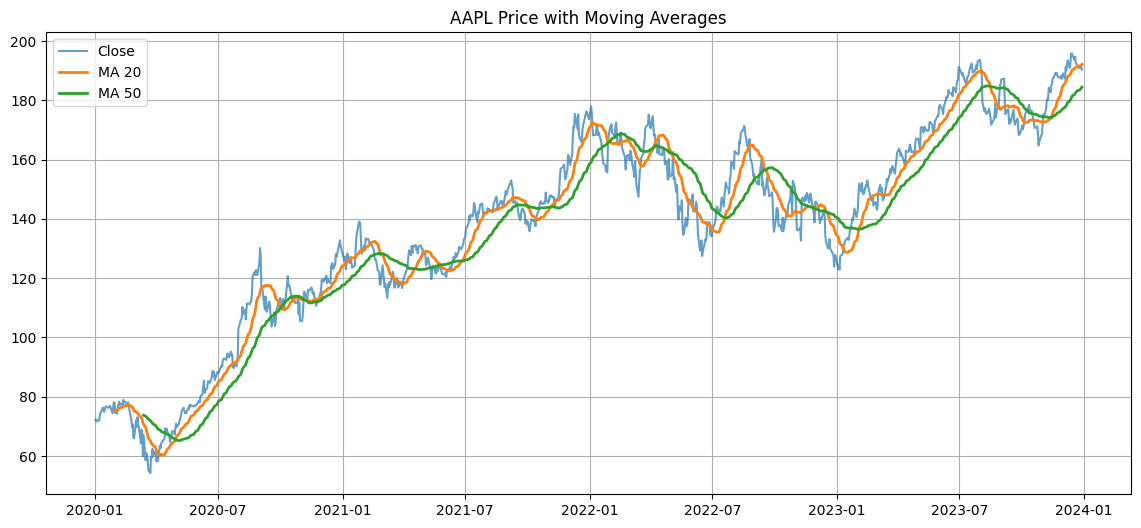

In [2]:
# MA = average closing price over last N days
# When MA20 crosses above MA50 = buy signal
# When MA20 crosses below MA50 = sell signal

df["MA_20"] = df["Close"].rolling(20).mean()
df["MA_50"] = df["Close"].rolling(50).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close", alpha=0.7)
plt.plot(df.index, df["MA_20"], label="MA 20", linewidth=2)
plt.plot(df.index, df["MA_50"], label="MA 50", linewidth=2)
plt.title("AAPL Price with Moving Averages")
plt.legend()
plt.grid(True)
plt.show()

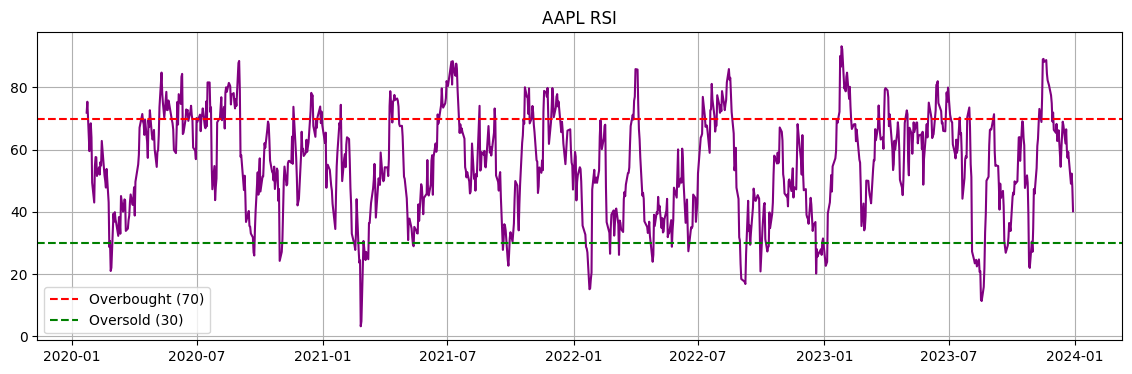

In [3]:
# RSI = measures if a stock is overbought or oversold
# Above 70 = overbought (price might drop soon)
# Below 30 = oversold (price might rise soon)

delta = df["Close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
df["RSI"] = 100 - (100 / (1 + gain / loss))

plt.figure(figsize=(14, 4))
plt.plot(df.index, df["RSI"], color="purple")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.title("AAPL RSI")
plt.legend()
plt.grid(True)
plt.show()

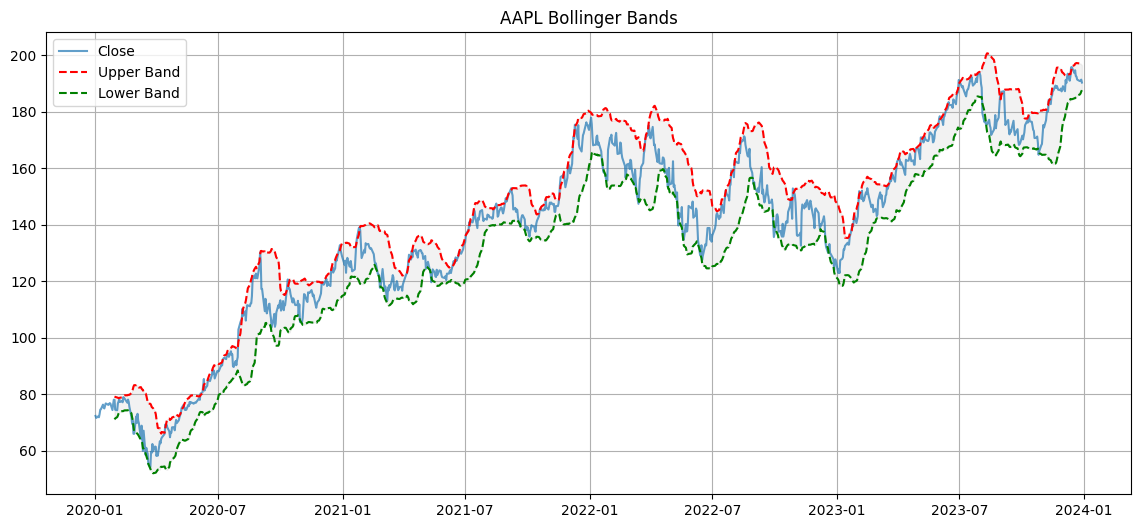

In [4]:
# Bollinger Bands = price channel around moving average
# When price hits upper band = potentially overbought
# When price hits lower band = potentially oversold

df["BB_Upper"] = df["MA_20"] + 2 * df["Close"].rolling(20).std()
df["BB_Lower"] = df["MA_20"] - 2 * df["Close"].rolling(20).std()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"], label="Close", alpha=0.7)
plt.plot(df.index, df["BB_Upper"], label="Upper Band", linestyle="--", color="red")
plt.plot(df.index, df["BB_Lower"], label="Lower Band", linestyle="--", color="green")
plt.fill_between(df.index, df["BB_Upper"], df["BB_Lower"], alpha=0.1, color="gray")
plt.title("AAPL Bollinger Bands")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
print(df[["Close", "MA_20", "MA_50", "RSI", "BB_Upper", "BB_Lower"]].tail(10))

                 Close       MA_20       MA_50        RSI    BB_Upper  \
Date                                                                    
2023-12-15  195.358673  190.369629  181.615970  67.844138  196.214755   
2023-12-18  193.697464  190.676160  181.984469  62.002726  196.545363   
2023-12-19  194.735703  190.947588  182.344107  66.535588  197.047770   
2023-12-20  192.649323  191.154742  182.673869  59.991785  197.186857   
2023-12-21  192.500977  191.321357  182.972816  57.388231  197.306394   
2023-12-22  191.433105  191.500827  183.232433  59.246201  197.257697   
2023-12-26  190.889267  191.662003  183.517908  49.032036  197.140554   
2023-12-27  190.988129  191.797966  183.807928  52.291466  197.052338   
2023-12-28  191.413330  192.006110  184.137460  47.920519  196.812718   
2023-12-29  190.375061  192.133665  184.472099  40.185159  196.596047   

              BB_Lower  
Date                    
2023-12-15  184.524502  
2023-12-18  184.806957  
2023-12-19  184.847405 

In [6]:
import sys
sys.path.append("C:/Users/Gouri/OneDrive/Documents/stock-analysis")
from src.features import add_features

df_featured = add_features(df.copy())
print(df_featured.shape)
print(df_featured.columns.tolist())

(957, 12)
['Close', 'High', 'Low', 'Open', 'Volume', 'MA_20', 'MA_50', 'RSI', 'BB_Upper', 'BB_Lower', 'Daily_Return', 'Volatility']
